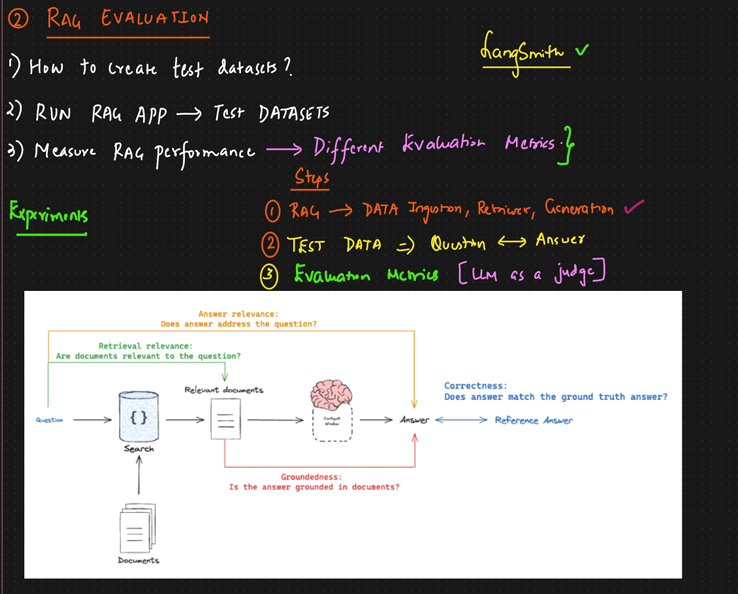

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["LANGSMITH_API_KEY"]=os.getenv("LANGSMITH_API_KEY")
os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["LANGSMITH_TRACING"]="true"

In [4]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model_name="gpt-4o", temperature=0)
llm 

ChatOpenAI(profile={'max_input_tokens': 128000, 'max_output_tokens': 16384, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x00000139BFCC98E0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x00000139BFD6B200>, root_client=<openai.OpenAI object at 0x00000139BFD02CC0>, root_async_client=<openai.AsyncOpenAI object at 0x00000139BFD68BF0>, model_name='gpt-4o', temperature=0.0, model_kwargs={}, openai_api_key=SecretStr('**********'), stream_usage=True)

In [3]:
## RAG
from langchain_community.document_loaders import WebBaseLoader
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_openai import OpenAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

# List of URLs to load documents from
urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
]

# Load documents from the URLs
docs = [WebBaseLoader(url).load() for url in urls]
docs_list = [item for sublist in docs for item in sublist]

# Initialize a text splitter with specified chunk size and overlap
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=250, chunk_overlap=0
)

# Split the documents into chunks
doc_splits = text_splitter.split_documents(docs_list)

# Add the document chunks to the "vector store" using OpenAIEmbeddings
vectorstore = InMemoryVectorStore.from_documents(
    documents=doc_splits,
    embedding=OpenAIEmbeddings(),
)

# With langchain we can easily turn any vector store into a retrieval component:
retriever = vectorstore.as_retriever(k=6)

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [5]:
retriever.invoke("what is agents")

[Document(id='1a3fa0f6-6151-4f2c-b2bf-2a7fa9ec5b41', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, 

In [6]:
from langsmith import traceable

## Add Decorator-- Automatically it will enable tracing

@traceable()
def rag_bot(question:str) -> dict:
    ## Relevant Context
    docs = retriever.invoke(question)
    docs_string = " ".join(doc.page_content for doc in docs)

    instructions = f"""You are a helpful assistant who is good at analyzing source information and answering questions.       
    Use the following source documents to answer the user's questions.       
    If you don't know the answer, just say that you don't know.       
    Use three sentences maximum and keep the answer concise

    Documents:
    {docs_string}
    """
    ## Invoke LLM

    ai_msg = llm.invoke([
        {"role":"system","content":instructions},
        {"role" : "user","content":question},
    ])

    return {"answer":ai_msg.content,"documents":docs}


In [7]:
rag_bot("What is Agents")

{'answer': 'Agents, in the context of the provided documents, refer to LLM-powered autonomous systems that simulate human-like behavior and decision-making. These agents are designed to operate in environments, interact with other agents, and perform tasks by utilizing components such as planning, memory, and reflection. They are used in various applications, including simulations like Generative Agents, which mimic human behavior in interactive settings.',
 'documents': [Document(id='1a3fa0f6-6151-4f2c-b2bf-2a7fa9ec5b41', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful 

### DataSets

In [8]:
from langsmith import Client
client = Client()
# Define the examples for the dataset
examples = [
    {
        "inputs": {"question": "How does the ReAct agent use self-reflection? "},
        "outputs": {"answer": "ReAct integrates reasoning and acting, performing actions - such tools like Wikipedia search API - and then observing / reasoning about the tool outputs."},
    },
    {
        "inputs": {"question": "What are the types of biases that can arise with few-shot prompting?"},
        "outputs": {"answer": "The biases that can arise with few-shot prompting include (1) Majority label bias, (2) Recency bias, and (3) Common token bias."},
    },
    {
        "inputs": {"question": "What are five types of adversarial attacks?"},
        "outputs": {"answer": "Five types of adversarial attacks are (1) Token manipulation, (2) Gradient based attack, (3) Jailbreak prompting, (4) Human red-teaming, (5) Model red-teaming."},
    }
]

### create the daatset and example in LAngsmith
dataset_name ="RAG Test Evaluation"
dataset = client.create_dataset(dataset_name=dataset_name)
client.create_examples(
    dataset_id=dataset.id,
    examples= examples
)


{'example_ids': ['c06fad1e-dd8c-4803-8954-8d1959e71d9e',
  '5b308afe-1f2d-41d0-a274-695543e2cfec',
  '74becd67-54cc-4a6c-9df3-13515a0f8440'],
 'count': 3}

### Evaluators or Metrics
1. Correctness: Response vs reference answer
- Goal: Measure "how similar/correct is the RAG chain answer, relative to a ground-truth answer"
- Mode: Requires a ground truth (reference) answer supplied through a dataset
- Evaluator: Use LLM-as-judge to assess answer correctness.

In [9]:
from typing_extensions import Annotated,TypedDict
## Correctness Output Schema
## Grade output schema

class CorrectnessGrade(TypedDict):
    explanation: Annotated[str,...,"Explain your reasoning for the score"]
    correct: Annotated[bool, ...,"True if the answer is correct, Flase otherwise."]


## correctness prompt
correctness_instructions = """You are a teacher grading a quiz. 

You will be given a QUESTION, the GROUND TRUTH (correct) ANSWER, and the STUDENT ANSWER. 

Here is the grade criteria to follow:
(1) Grade the student answers based ONLY on their factual accuracy relative to the ground truth answer. 
(2) Ensure that the student answer does not contain any conflicting statements.
(3) It is OK if the student answer contains more information than the ground truth answer, as long as it is factually accurate relative to the  ground truth answer.

Correctness:
A correctness value of True means that the student's answer meets all of the criteria.
A correctness value of False means that the student's answer does not meet all of the criteria.

Explain your reasoning in a step-by-step manner to ensure your reasoning and conclusion are correct. 

Avoid simply stating the correct answer at the outset."""


from langchain_openai import ChatOpenAI
grader_llm = ChatOpenAI(model="gpt-4o",temperature=0).with_structured_output(CorrectnessGrade, method="json_schema",strict=True)


## Evaluator 

def correctness(inputs: dict, outputs: dict, reference_outputs: dict) -> bool:
    """An evaluator for RAG answer accuracy"""
    
    answers = f"""  QUESTION: {inputs['question']}
                    GROUND TRUTH ANSWER: {reference_outputs['answer']}
                    STUDENT ANSWER: {outputs['answer']}
    """

    grade = grader_llm.invoke([
        {"role": "system", "content": correctness_instructions}, 
            {"role": "user", "content": answers}
    ])
    return grade["correct"]

### Relevance: Response vs input
The flow is similar to above, but we simply look at the inputs and outputs without needing the reference_outputs. Without a reference answer we can't grade accuracy, but can still grade relevance—as in, did the model address the user's question or not.

In [10]:
# Grade output schema
class RelevanceGrade(TypedDict):
    explanation: Annotated[str, ..., "Explain your reasoning for the score"]
    relevant: Annotated[bool, ..., "Provide the score on whether the answer addresses the question"]

# Grade prompt
relevance_instructions="""You are a teacher grading a quiz. 
        You will be given a QUESTION and a STUDENT ANSWER. 
        Here is the grade criteria to follow:
        (1) Ensure the STUDENT ANSWER is concise and relevant to the QUESTION
        (2) Ensure the STUDENT ANSWER helps to answer the QUESTION

        Relevance:
        A relevance value of True means that the student's answer meets all of the criteria.
        A relevance value of False means that the student's answer does not meet all of the criteria.

        Explain your reasoning in a step-by-step manner to ensure your reasoning and conclusion are correct. 

        Avoid simply stating the correct answer at the outset.
        """

# Grader LLM
relevance_llm = ChatOpenAI(model="gpt-4o", temperature=0).with_structured_output(RelevanceGrade, method="json_schema", strict=True)

# Evaluator
def relevance(inputs: dict, outputs: dict) -> bool:
    """A simple evaluator for RAG answer helpfulness."""
    answer = f"QUESTION: {inputs['question']}\nSTUDENT ANSWER: {outputs['answer']}"
    grade = relevance_llm.invoke([
        {"role": "system", "content": relevance_instructions}, 
        {"role": "user", "content": answer}
    ])
    return grade["relevant"]

### Groundedness: Response vs retrieved docs
Another useful way to evaluate responses without needing reference answers is to check if the response is justified by (or "grounded in") the retrieved documents.

In [11]:
# Grade output schema
class GroundedGrade(TypedDict):
    explanation: Annotated[str, ..., "Explain your reasoning for the score"]
    grounded: Annotated[bool, ..., "Provide the score on if the answer hallucinates from the documents"]

# Grade prompt
grounded_instructions = """You are a teacher grading a quiz. 

You will be given FACTS and a STUDENT ANSWER. 

Here is the grade criteria to follow:
(1) Ensure the STUDENT ANSWER is grounded in the FACTS. 
(2) Ensure the STUDENT ANSWER does not contain "hallucinated" information outside the scope of the FACTS.

Grounded:
A grounded value of True means that the student's answer meets all of the criteria.
A grounded value of False means that the student's answer does not meet all of the criteria.

Explain your reasoning in a step-by-step manner to ensure your reasoning and conclusion are correct. 

Avoid simply stating the correct answer at the outset."""

# Grader LLM 
grounded_llm = ChatOpenAI(model="gpt-4o", temperature=0).with_structured_output(GroundedGrade, method="json_schema", strict=True)

# Evaluator
def groundedness(inputs: dict, outputs: dict) -> bool:
    """A simple evaluator for RAG answer groundedness."""
    doc_string = "\n\n".join(doc.page_content for doc in outputs["documents"])
    answer = f"FACTS: {doc_string}\nSTUDENT ANSWER: {outputs['answer']}"
    grade = grounded_llm.invoke([{"role": "system", "content": grounded_instructions}, {"role": "user", "content": answer}])
    return grade["grounded"]

### Retrieval Relevance: Retrieved docs vs input

In [12]:
# Grade output schema
class RetrievalRelevanceGrade(TypedDict):
    explanation: Annotated[str, ..., "Explain your reasoning for the score"]
    relevant: Annotated[bool, ..., "True if the retrieved documents are relevant to the question, False otherwise"]

# Grade prompt
retrieval_relevance_instructions = """You are a teacher grading a quiz. 

You will be given a QUESTION and a set of FACTS provided by the student. 

Here is the grade criteria to follow:
(1) You goal is to identify FACTS that are completely unrelated to the QUESTION
(2) If the facts contain ANY keywords or semantic meaning related to the question, consider them relevant
(3) It is OK if the facts have SOME information that is unrelated to the question as long as (2) is met

Relevance:
A relevance value of True means that the FACTS contain ANY keywords or semantic meaning related to the QUESTION and are therefore relevant.
A relevance value of False means that the FACTS are completely unrelated to the QUESTION.

Explain your reasoning in a step-by-step manner to ensure your reasoning and conclusion are correct. 

Avoid simply stating the correct answer at the outset."""

# Grader LLM
retrieval_relevance_llm = ChatOpenAI(model="gpt-4o", temperature=0).with_structured_output(RetrievalRelevanceGrade, method="json_schema", strict=True)

def retrieval_relevance(inputs: dict, outputs: dict) -> bool:
    """An evaluator for document relevance"""
    doc_string = "\n\n".join(doc.page_content for doc in outputs["documents"])
    answer = f"FACTS: {doc_string}\nQUESTION: {inputs['question']}"

    # Run evaluator
    grade = retrieval_relevance_llm.invoke([
        {"role": "system", "content": retrieval_relevance_instructions}, 
        {"role": "user", "content": answer}
    ])
    return grade["relevant"]

### Run the evaluation

In [13]:
def target(inputs: dict) -> dict:
    return rag_bot(inputs["question"])

experiment_results = client.evaluate(
    target,
    data=dataset_name,
    evaluators=[correctness, groundedness, relevance, retrieval_relevance],
    experiment_prefix="rag-doc-relevance",
    metadata={"version": "LCEL context, gpt-4-0125-preview"},
)
# Explore results locally as a dataframe if you have pandas installed
experiment_results.to_pandas()

View the evaluation results for experiment: 'rag-doc-relevance-7f04dd9e' at:
https://smith.langchain.com/o/29151346-6207-4c13-85e7-07f2906fe5c4/datasets/3d2b9f61-9ebd-4a2c-822e-406632d33d58/compare?selectedSessions=db331c8d-6147-4c38-98a3-38f2c0ab5812




0it [00:00, ?it/s]

,inputs.question,outputs.answer,outputs.documents,error,reference.answer,feedback.correctness,feedback.groundedness,feedback.relevance,feedback.retrieval_relevance,execution_time,example_id,id
0,How does the ReAct agent use self-reflection?,The ReAct agent does not explicitly use self-r...,[page_content='Self-reflection is a vital aspe...,None,"ReAct integrates reasoning and acting, perform...",True,True,True,False,2.419509,5b308afe-1f2d-41d0-a274-695543e2cfec,019c62ca-8cfb-7880-b479-5f8d79b2f1bc
1,What are the types of biases that can arise wi...,The types of biases that can arise with few-sh...,[page_content='Zero-shot and few-shot learning...,None,The biases that can arise with few-shot prompt...,True,True,True,True,2.076479,74becd67-54cc-4a6c-9df3-13515a0f8440,019c62ca-cd26-7232-8236-1953932ad937
2,What are five types of adversarial attacks?,The five types of adversarial attacks are toke...,[page_content='Black-box attacks assume that a...,None,Five types of adversarial attacks are (1) Toke...,True,True,True,True,1.745490,c06fad1e-dd8c-4803-8954-8d1959e71d9e,019c62ca-f994-7920-844d-7ebeb55a9d6f
